In [182]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

### 1) Data Collection

In [183]:
df = pd.read_csv(r"data.csv")

The only gap is engine CC — that dataset has engine cylinders and displacement, not CC directly. But displacement in liters × 1000 = CC approximately, so you can engineer that feature.

In [184]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [185]:
print(df.shape)

(11914, 16)


### 2) Data Cleaning

In [186]:
df.drop(columns=['Make', 'Model', 'Year', 'MSRP', 'Popularity',
                 'Number of Doors', 'Market Category'], inplace=True)

In [187]:
print(df.isnull().sum())

Engine Fuel Type      3
Engine HP            69
Engine Cylinders     30
Transmission Type     0
Driven_Wheels         0
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
dtype: int64


In [188]:
# Remove null vaues from Engine Fuel type Column

df = df[df['Engine Fuel Type'].notna()]

In [189]:
# Remove null vaues from Engine Cylinders Column

df.groupby('Engine Fuel Type')['Engine Cylinders'].transform(
    lambda x: x.fillna(x.median()))

0        6.0
1        6.0
2        6.0
3        6.0
4        6.0
        ... 
11909    6.0
11910    6.0
11911    6.0
11912    6.0
11913    6.0
Name: Engine Cylinders, Length: 11911, dtype: float64

In [190]:
print(df.isnull().sum())

Engine Fuel Type      0
Engine HP            69
Engine Cylinders     30
Transmission Type     0
Driven_Wheels         0
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
dtype: int64


In [191]:
# combined Highway and city milage in to singlwe column

df['Combined_mpg'] = (df['highway MPG'] + df['city mpg']) / 2

In [192]:
# Droped Highway_mpg and City_mpg columns
df.drop(columns=['highway MPG', 'city mpg'], inplace=True)

In [193]:
df.columns

Index(['Engine Fuel Type', 'Engine HP', 'Engine Cylinders',
       'Transmission Type', 'Driven_Wheels', 'Vehicle Size', 'Vehicle Style',
       'Combined_mpg'],
      dtype='object')

In [194]:
# Added Engine CC column into the dataframe
df['Engine_CC'] = df['Engine Cylinders'] * 500

### 3) EDA (Exploratory data analysis)

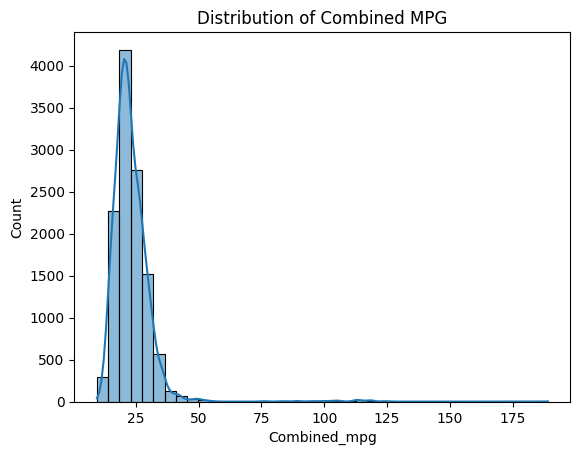

In [195]:
sns.histplot(df['Combined_mpg'], bins=40, kde=True)
plt.title('Distribution of Combined MPG')
plt.show()

In [196]:
df.columns

Index(['Engine Fuel Type', 'Engine HP', 'Engine Cylinders',
       'Transmission Type', 'Driven_Wheels', 'Vehicle Size', 'Vehicle Style',
       'Combined_mpg', 'Engine_CC'],
      dtype='object')

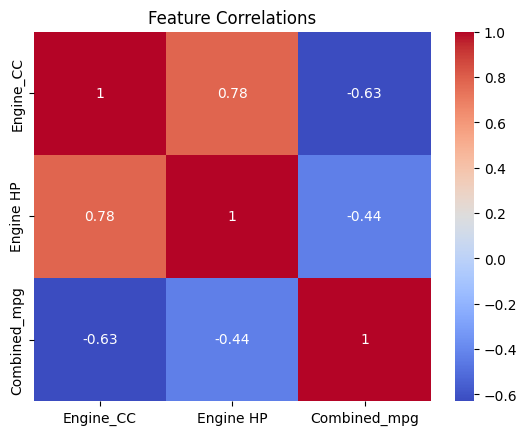

In [197]:
sns.heatmap(df[['Engine_CC', 'Engine HP', 'Combined_mpg']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

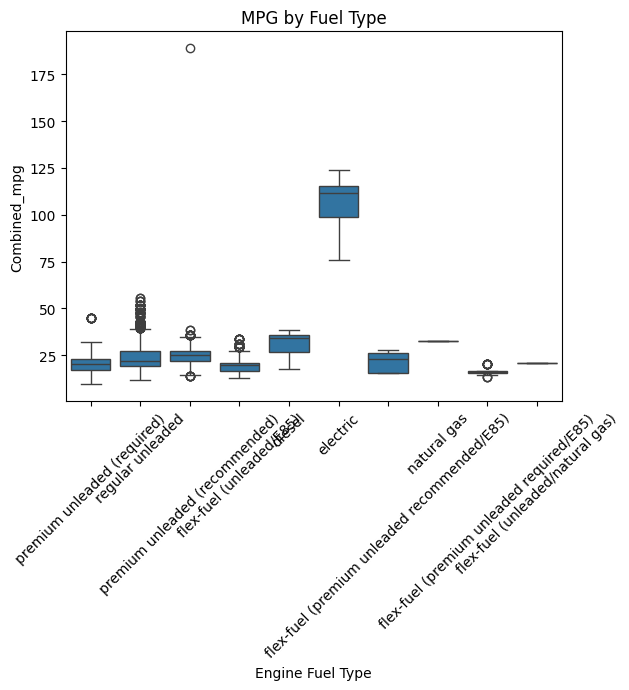

In [198]:
sns.boxplot(x='Engine Fuel Type', y='Combined_mpg', data=df)
plt.title('MPG by Fuel Type')
plt.xticks(rotation=45)
plt.show()

In [199]:
df = df[df['Engine Fuel Type'] != 'electric'].dropna()

In [200]:
# Check
print(df['Engine Fuel Type'].dtype)
print(df['Transmission Type'].dtype)
print(df['Driven_Wheels'].dtype)
print(df['Vehicle Size'].dtype)
print(df['Vehicle Style'].dtype)

object
object
object
object
object


In [201]:
le_fuel = LabelEncoder()
le_trans = LabelEncoder()
le_drive = LabelEncoder()
le_size = LabelEncoder()
le_style = LabelEncoder()

df['fuel_enc'] = le_fuel.fit_transform(df['Engine Fuel Type'])
df['trans_enc'] = le_trans.fit_transform(df['Transmission Type'])
df['drive_enc'] = le_drive.fit_transform(df['Driven_Wheels'])
df['size_enc'] = le_size.fit_transform(df['Vehicle Size'])
df['style_enc'] = le_style.fit_transform(df['Vehicle Style'])

In [202]:
df[['Engine Fuel Type', 'fuel_enc']].drop_duplicates().sort_values('fuel_enc')

,Engine Fuel Type,fuel_enc
135,diesel,0
804,flex-fuel (premium unleaded recommended/E85),1
2850,flex-fuel (premium unleaded required/E85),2
64,flex-fuel (unleaded/E85),3
2556,natural gas,4
32,premium unleaded (recommended),5
0,premium unleaded (required),6
17,regular unleaded,7


In [203]:
def simplify_fuel(f):
    f = f.lower()
    if 'diesel' in f:
        return 'Diesel'
    if 'premium' in f:
        return 'Premium'
    if 'flex' in f or 'natural' in f:
        return 'Flex/Other'
    return 'Petrol'


df['Engine Fuel Type'] = df['Engine Fuel Type'].apply(simplify_fuel)

In [204]:
# Feature selection
features = ['Engine_CC', 'Engine HP', 'fuel_enc', 'trans_enc',
            'drive_enc', 'size_enc', 'style_enc']

X = df[features]
y = df['Combined_mpg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (9440, 7)
X_test shape: (2360, 7)
y_train shape: (9440,)
y_test shape: (2360,)


In [205]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print('Training done ✅')

Training done ✅


In [206]:
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R² Score : {r2:.4f}')
print(f'MAE      : {mae:.2f} MPG')

R² Score : 0.9586
MAE      : 0.61 MPG


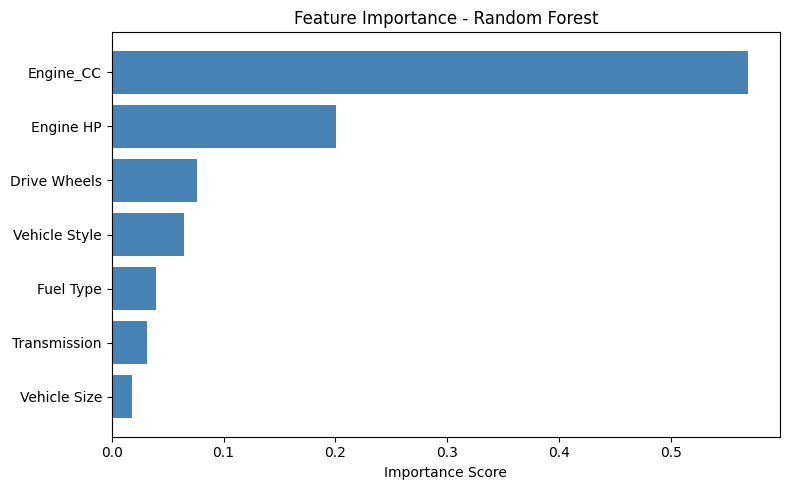

In [207]:
feature_names = ['Engine_CC', 'Engine HP', 'Fuel Type',
                 'Transmission', 'Drive Wheels', 'Vehicle Size', 'Vehicle Style']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'],
         importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

In [208]:
# Save model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Save all encoders
encoders = {
    'fuel':  le_fuel,
    'trans': le_trans,
    'drive': le_drive,
    'size':  le_size,
    'style': le_style
}

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print('Model and encoders saved ✅')

Model and encoders saved ✅


In [209]:
import os
print(os.path.exists('rf_model.pkl'))    # True
print(os.path.exists('encoders.pkl'))    # True

True
True
